<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Sun Aug  3 01:36:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.6.0+cu124


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

My guesses are...
  1. Self-driving vehicles
  2. Detection of bad products in a production line
  3. Detection of cracks in the pavement

For some googled uses I found
  1. Facial Recognition (like FaceID for example)
  2. E-commerce product tagging
  3. Diagnostics in Medical Imaging (X-Rays, MRIs, CT Scans)

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

Overfitting is when a machine learning model starts to mistake noise in the data as part of the integral relationship between input data and the target output.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1. Get more data to train on your model
2. Try regularization techniques such as Dropout Regularization or L1, L2 regularization.
3. Try a different architecture (which may somewhat help but isn't really the first choice)
4. Some blogs out there mention `Feature Selection`

    "If we have only a limited amount of training samples, each with a large number of features, we should only select the most important features for training so that our model doesn’t need to learn for so many features and eventually overfit. We can simply test out different features, train individual models for these features, and evaluate generalization capabilities, or use one of the various widely used feature selection methods".


## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
import torchvision
from torchvision import datasets

In [4]:
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.07MB/s]


In [5]:
len(train_data), len(test_data)

(60000, 10000)

## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [6]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [7]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [8]:
import matplotlib.pyplot as plt
import torch

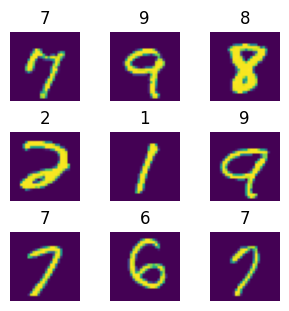

In [9]:
fig = plt.figure(figsize=(3,3), constrained_layout=True)
rows, cols = 3, 3
for i in range(1, (rows*cols)+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  #print(img.shape, label)
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze())
  plt.title(label)
  plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [10]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader_mnist = DataLoader(
    dataset = train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataloader_mnist = DataLoader(
    dataset = test_data,
    batch_size = BATCH_SIZE,
    shuffle = False # Shuffling not necessary for test data
)

In [11]:
train_dataloader_mnist, test_dataloader_mnist

(<torch.utils.data.dataloader.DataLoader at 0x7e60d2f2ef90>,
 <torch.utils.data.dataloader.DataLoader at 0x7e60d2eaa210>)

In [12]:
print(f"Train dataloader has {len(train_dataloader_mnist)} batches of size {BATCH_SIZE}")
print(f"   To see if it divides neatly: {len(train_data) % BATCH_SIZE} (if 0 then it does.)")
print(f"Test dataloader has {len(test_dataloader_mnist)} batches of size {BATCH_SIZE}")
print(f"   To see if it divides neatly: {len(test_data) % BATCH_SIZE} (if 0 then it does.)")

Train dataloader has 1875 batches of size 32
   To see if it divides neatly: 0 (if 0 then it does.)
Test dataloader has 313 batches of size 32
   To see if it divides neatly: 16 (if 0 then it does.)


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [13]:
from torch import nn

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

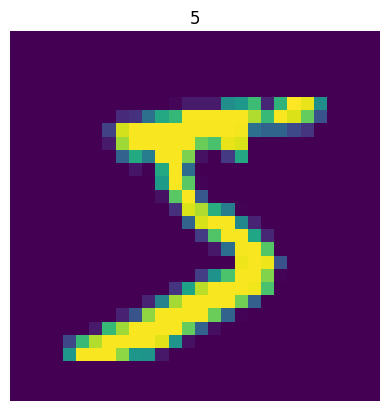

In [14]:
image, label = train_data[0]
plt.imshow(image.squeeze())
plt.title(label)
plt.axis(False)

In [15]:
image.shape, len(class_names)

(torch.Size([1, 28, 28]), 10)

In [16]:
import torch
from torch import nn

In [17]:
class MNISTModelV0(nn.Module):
  def __init__(self, input_shape : int, hidden_units : int, output_shape : int):
    super().__init__()
    self.block1 = nn.Sequential(
        nn.Conv2d(
            in_channels=input_shape,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=0
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=0
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.block2 = nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=0
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=0
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier_block = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_units*4*4,
            out_features=output_shape
        )
    )

  def forward(self, x):
    x = self.block1(x)
    #print(f"Shape after block 1: {x.shape}")
    x = self.block2(x)
    #print(f"Shape after block 2: {x.shape}")
    x = self.classifier_block(x)
    return x

In [18]:
model_1 = MNISTModelV0(
    input_shape = 1,
    hidden_units = 10,
    output_shape = len(class_names)
).to(device)

In [19]:
image.shape

torch.Size([1, 28, 28])

In [20]:
model_1.forward(image.unsqueeze(dim=0).to(device)) #ALWAYS remember to add a `batch` dimension at the beginning!!!

tensor([[-0.0764,  0.0153, -0.0293,  0.0003,  0.0466,  0.0493,  0.0695, -0.1011,
         -0.0050, -0.0515]], device='cuda:0', grad_fn=<AddmmBackward0>)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [21]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download...")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [22]:
from helper_functions import accuracy_fn

In [23]:
loss_fn_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.1
)
loss_fn = None
optimizer = None

In [24]:
y_logits = model_1(image.unsqueeze(dim=0).to(device))
print(y_logits, y_logits.shape)
print("----------------------")
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_pred_probs, y_pred_probs.shape)
print("----------------------")
y_pred = torch.argmax(y_pred_probs, dim=1)
y_pred

tensor([[-0.0764,  0.0153, -0.0293,  0.0003,  0.0466,  0.0493,  0.0695, -0.1011,
         -0.0050, -0.0515]], device='cuda:0', grad_fn=<AddmmBackward0>) torch.Size([1, 10])
----------------------
tensor([[0.0933, 0.1022, 0.0978, 0.1007, 0.1055, 0.1058, 0.1079, 0.0910, 0.1002,
         0.0956]], device='cuda:0', grad_fn=<SoftmaxBackward0>) torch.Size([1, 10])
----------------------


tensor([6], device='cuda:0')

In [25]:
import random
random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples = torch.stack(test_samples, dim=0).to(device)

In [26]:
test_samples.shape

torch.Size([9, 1, 28, 28])

In [27]:
y_logits_test = model_1(test_samples)

y_pred_probs_test = torch.softmax(y_logits_test, dim=1)
y_preds_test = torch.argmax(y_pred_probs_test, dim=1)

print(y_logits_test.shape, y_pred_probs_test.shape, y_preds_test.shape)

torch.Size([9, 10]) torch.Size([9, 10]) torch.Size([9])


In [28]:
def train_step(
    model : torch.nn.Module,
    train_dataloader : torch.utils.data.DataLoader,
    loss_fn : torch.nn.Module,
    optimizer : torch.optim.Optimizer,
    accuracy_fn,
    device : torch.device = device
):
  train_loss, train_acc = 0, 0
  model.train()
  for index, (X, y) in enumerate(train_dataloader):

    X, y = X.to(device), y.to(device)

    # FWD
    y_logits = model(X)

    # Loss
    train_batch_loss = loss_fn(y_logits, y)
    train_loss += train_batch_loss

    # Accuracy
    y_pred_probs = torch.softmax(y_logits, dim=1)
    y_preds = torch.argmax(y_pred_probs, dim=1)
    train_batch_acc = accuracy_fn(y_true=y, y_pred=y_preds)
    train_acc += train_batch_acc

    # Optimizer zero grad
    optimizer.zero_grad()

    # Loss Backward
    train_batch_loss.backward()

    # Optimizer
    optimizer.step()

    if index % 500 == 0:
      print(f"Looked at {(index+1)*len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)
  print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}")

In [29]:
def test_step(
    model : torch.nn.Module,
    test_dataloader : torch.utils.data.DataLoader,
    loss_fn : torch.nn.Module,
    accuracy_fn,
    device : torch.device = device
):
  test_loss, test_acc = 0, 0

  model.eval()
  with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
      X, y = X.to(device), y.to(device)

      # Forward pass
      test_logits = model(X)

      # Loss
      test_batch_loss = loss_fn(test_logits, y)
      test_loss += test_batch_loss

      # Accuracy
      test_pred_probs = torch.softmax(test_logits, dim=1)
      test_preds = torch.argmax(test_pred_probs, dim=1)
      test_batch_acc = accuracy_fn(y_true=y, y_pred=test_preds)
      test_acc += test_batch_acc

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}")

In [30]:
from tqdm.auto import tqdm

In [31]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
  total_time = end - start
  print(f"Total time on {device} : {total_time:.3f}")
  return total_time

In [32]:
def train(
    model: nn.Module,
    epochs : int,
    train_dataloader : torch.utils.data.DataLoader,
    test_dataloader : torch.utils.data.DataLoader,
    loss_fn : torch.nn.Module,
    optimizer : torch.optim.Optimizer,
    accuracy_fn,
    device : torch.device = device
):
  torch.manual_seed(42)
  start_timer = timer()

  for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch} ---------------")

    train_step(
        model=model,
        train_dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(
        model=model,
        test_dataloader = test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )
  end_timer = timer()
  print_train_time(start=start_timer, end=end_timer, device=device)

In [33]:
train(
    model=model_1,
    epochs=3,
    train_dataloader=train_dataloader_mnist,
    test_dataloader=test_dataloader_mnist,
    loss_fn = loss_fn_cnn,
    optimizer = optimizer_cnn,
    accuracy_fn = accuracy_fn,
    device=device
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0 ---------------
Looked at 32/60000 samples
Looked at 16032/60000 samples
Looked at 32032/60000 samples
Looked at 48032/60000 samples
Train Loss: 0.3635 | Train Accuracy: 87.37
Test Loss: 0.0818 | Test Accuracy: 97.37
Epoch 1 ---------------
Looked at 32/60000 samples
Looked at 16032/60000 samples
Looked at 32032/60000 samples
Looked at 48032/60000 samples
Train Loss: 0.0779 | Train Accuracy: 97.61
Test Loss: 0.0532 | Test Accuracy: 98.14
Epoch 2 ---------------
Looked at 32/60000 samples
Looked at 16032/60000 samples
Looked at 32032/60000 samples
Looked at 48032/60000 samples
Train Loss: 0.0608 | Train Accuracy: 98.10
Test Loss: 0.0528 | Test Accuracy: 98.28
Total time on cuda : 38.058


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [34]:
import random
random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples_tensor = torch.stack(test_samples, dim=0).to(device)
test_samples_tensor.shape

torch.Size([9, 1, 28, 28])

In [35]:
model_1.eval()
y_samples_logits = model_1(test_samples_tensor.to(device))
y_samples_predprobs = torch.softmax(y_samples_logits, dim=1)
y_samples_preds = torch.argmax(y_samples_predprobs, dim=1)
y_samples_preds = y_samples_preds.to("cpu")
y_samples_preds.shape

torch.Size([9])

In [36]:
y_samples_preds[8]

tensor(1)

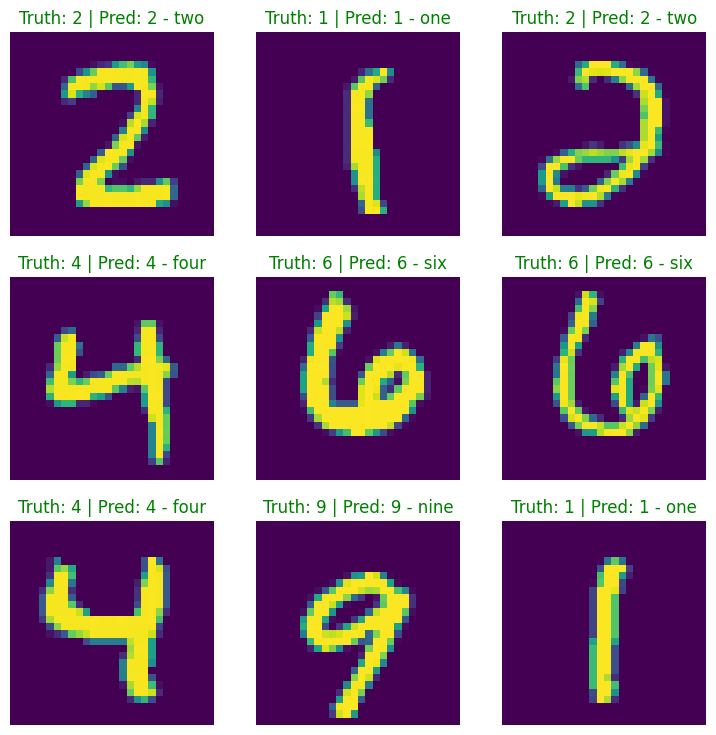

In [37]:
nrows, ncols = 3, 3
plt.figure(figsize=(9,9))
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze())
  plt.axis(False)
  plt.title(f"Truth: {test_labels[i]} | Pred: {class_names[y_samples_preds[i]]}", c="g" if True else "r")

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [38]:
try:
  import torchmetrics, mlxtend
  print(f"MLXtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "MLXTend version should be 19 or higher"
except:
  print(f"Installing torchmetrics, mlxtend")
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

Installing torchmetrics, mlxtend
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.3 MB/s eta 0:00:00
mlxtend version: 0.23.4


In [39]:
def get_preds_tensor(model : nn.Module, dataloader : torch.utils.data.DataLoader):
  """ Returns a tensor with all the predictions, for use in the confusion matrix
  """
  y_preds_list = []
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(dataloader, desc="Generating predictions from your model"):
      X, y = X.to(device), y.to(device)
      y_logits = model(X)
      y_predictions = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
      y_preds_list.append(y_predictions)
  return torch.cat(y_preds_list)

In [40]:
y_pred_tensor = get_preds_tensor(
    model=model_1,
    dataloader=test_dataloader_mnist
).to("cpu")
y_pred_tensor.shape

Generating predictions from your model:   0%|          | 0/313 [00:00<?, ?it/s]

torch.Size([10000])

In [41]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confusion_matrix = ConfusionMatrix(
    num_classes=len(class_names),
    task="multiclass"
)
confmat_tensor = confusion_matrix(
    preds = y_pred_tensor,
    target=test_data.targets
)

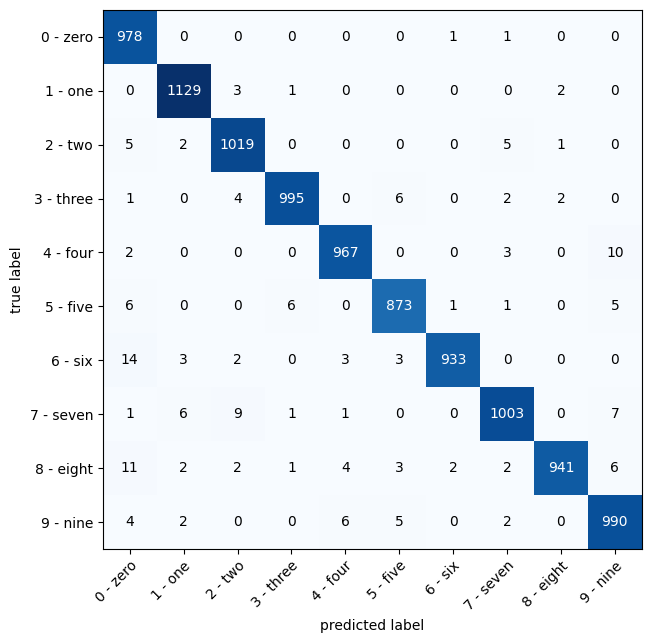

In [42]:
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [43]:
torch.manual_seed(42)
random_tensor = torch.randn((1, 3, 64, 64))
random_tensor.shape

torch.Size([1, 3, 64, 64])

In [44]:
from torch import nn

conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=1,
   padding=1,
   stride=1
)
print("KS 1 | P 1 | S 1 -----------")
print(conv2dLayer(random_tensor).shape)
conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=2,
   padding=1,
   stride=1
)
print("KS 2 | P 1 | S 1 -----------")
print(conv2dLayer(random_tensor).shape)
conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=3,
   padding=1,
   stride=1
)
print("KS 3 | P 1 | S 1 -----------")
print(conv2dLayer(random_tensor).shape)

KS 1 | P 1 | S 1 -----------
torch.Size([1, 10, 66, 66])
KS 2 | P 1 | S 1 -----------
torch.Size([1, 10, 65, 65])
KS 3 | P 1 | S 1 -----------
torch.Size([1, 10, 64, 64])


With an increasing Kernel Size, we seem to reduce the output image's size.

In [45]:
conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=1,
   padding=0,
   stride=1
)
print("KS 1 | P 0 | S 1 -----------")
print(conv2dLayer(random_tensor).shape)
conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=1,
   padding=1,
   stride=1
)
print("KS 1 | P 1 | S 1 -----------")
print(conv2dLayer(random_tensor).shape)
conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=1,
   padding=2,
   stride=1
)
print("KS 1 | P 2 | S 1 -----------")
print(conv2dLayer(random_tensor).shape)

KS 1 | P 0 | S 1 -----------
torch.Size([1, 10, 64, 64])
KS 1 | P 1 | S 1 -----------
torch.Size([1, 10, 66, 66])
KS 1 | P 2 | S 1 -----------
torch.Size([1, 10, 68, 68])


In [46]:
conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=1,
   padding=0,
   stride=1
)
print("KS 1 | P 0 | S 1 -----------")
print(conv2dLayer(random_tensor).shape)
conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=1,
   padding=0,
   stride=2
)
print("KS 1 | P 0 | S 2 -----------")
print(conv2dLayer(random_tensor).shape)
conv2dLayer = nn.Conv2d(
   in_channels=3,
   out_channels=10,
   kernel_size=1,
   padding=0,
   stride=3
)
print("KS 1 | P 0 | S 3 -----------")
print(conv2dLayer(random_tensor).shape)

KS 1 | P 0 | S 1 -----------
torch.Size([1, 10, 64, 64])
KS 1 | P 0 | S 2 -----------
torch.Size([1, 10, 32, 32])
KS 1 | P 0 | S 3 -----------
torch.Size([1, 10, 22, 22])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [47]:
train_fashion_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_fashion_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.79MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 56.9MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.27MB/s]


In [48]:
fashion_class_names = train_fashion_data.classes
fashion_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [49]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_fashion_dataloader = DataLoader(
    dataset = train_fashion_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_fashion_dataloader = DataLoader(
    dataset = test_fashion_data,
    batch_size = BATCH_SIZE,
    shuffle=False
)


In [50]:
from torch import nn

model_fashion = MNISTModelV0(
    input_shape= 1,
    hidden_units= 10,
    output_shape= len(fashion_class_names)
).to(device)

In [51]:
loss_fn_fashion = nn.CrossEntropyLoss()
optimizer_fashion = torch.optim.SGD(
    params=model_fashion.parameters(),
    lr=0.1
)

In [52]:
train(
    model=model_fashion,
    epochs=3,
    train_dataloader=train_fashion_dataloader,
    test_dataloader=test_fashion_dataloader,
    loss_fn=loss_fn_fashion,
    optimizer=optimizer_fashion,
    accuracy_fn=accuracy_fn
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0 ---------------
Looked at 32/60000 samples
Looked at 16032/60000 samples
Looked at 32032/60000 samples
Looked at 48032/60000 samples
Train Loss: 0.6784 | Train Accuracy: 75.01
Test Loss: 0.4545 | Test Accuracy: 83.53
Epoch 1 ---------------
Looked at 32/60000 samples
Looked at 16032/60000 samples
Looked at 32032/60000 samples
Looked at 48032/60000 samples
Train Loss: 0.4134 | Train Accuracy: 84.83
Test Loss: 0.3912 | Test Accuracy: 85.79
Epoch 2 ---------------
Looked at 32/60000 samples
Looked at 16032/60000 samples
Looked at 32032/60000 samples
Looked at 48032/60000 samples
Train Loss: 0.3694 | Train Accuracy: 86.52
Test Loss: 0.3963 | Test Accuracy: 86.14
Total time on cuda : 43.086


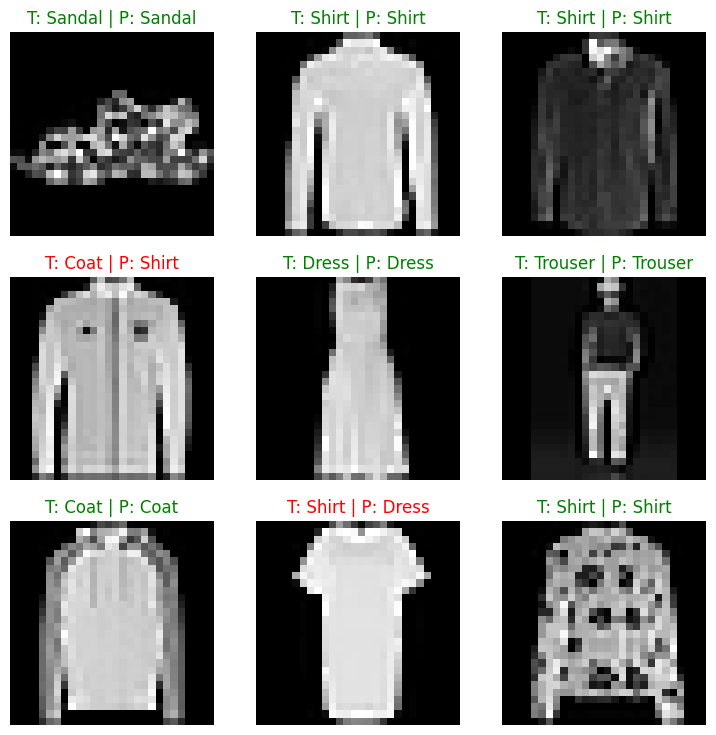

In [56]:
import random

random_fashion_samples = []
random_fashion_labels = []
for sample, label in random.sample(list(test_fashion_data), k=9):
  random_fashion_samples.append(sample)
  random_fashion_labels.append(label)

random_fashion_samples_tensor = torch.stack(random_fashion_samples, dim=0).to(device)

y_fashion_logits = model_fashion(random_fashion_samples_tensor)
y_fashion_preds = torch.argmax(torch.softmax(y_fashion_logits, dim=1), dim=1)

plt.figure(figsize=(9, 9))
nrows, ncols = 3, 3
for i, sample in enumerate(random_fashion_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.axis(False)
  plt.imshow(sample.squeeze(), cmap="gray")
  truth_label = fashion_class_names[random_fashion_labels[i]]
  pred_label = fashion_class_names[y_fashion_preds[i]]

  plt.title(f"T: {truth_label} | P: {pred_label}", c="g" if random_fashion_labels[i]==y_fashion_preds[i] else "r")

The issue seems to be that the labelling chosen is kind of odd. Sometimes we get items where it's ambiguous whether it's X or Y item, even to a human.

## ChatGPT metadata erasure for Github Upload

In [ ]:
import nbformat

notebook_path = '/content/drive/MyDrive/Colab Notebooks/03_pytorch_computer_vision_exercises.ipynb'  # Update as needed

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']
    print("Removed 'widgets' metadata.")
else:
    print("No 'widgets' metadata found.")

with open(notebook_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)
    print("Notebook cleaned and saved back to Drive.")
